# «Первичное исследование и оценка качества данных» (продолжение)

## 1. Типы признаков и шкалы измерения

### Задание 1.

### 1. Классификация признаков

| Признак | Тип шкалы | Обоснование |
|---|---|---|
| `season` | **Порядковая** | Есть логический порядок (весна, лето...), но интервалы между сезонами условны. |
| `holiday` | **Номинальная** | Бинарный признак. Значения 0 и 1 - метки категорий. |
| `weather` | **Порядковая** | Состояния погоды от "ясно" (1) до "ливень/снег" (4). Порядок важен, но разница между может быть разной. |
| `temp` | **Интервальная** | Измерение в градусах Цельсия. Можно вычислять разность, но не отношения. |
| `humidity` | **Абсолютная** | Есть ноль (0% влажности). Корректно утверждение "влажность выросла в 2 раза". |
| `count` | **Абсолютная** | Дискретная абсолютная шкала. Есть ноль (отсутствие аренд). |

### 2. Смысл агрегатов
Сравним признаки: `season` (порядковая) и `count` (асолютная).

1.  **Среднее арифметическое:**
    *   `count`: **Имеет смысл.** Показывает среднюю нагрузку на сервис.
    *   `season`: **Не имеет смысла.** Среднее число сезонов 2.5 не интерпретируемо.
2.  **Медиана:**
    *   `count`: **Имеет смысл.** Делит выборку пополам, показывает нагрузку.
    *   `season`: **Ограниченный смысл.** Можно сказать "половина наблюдений относится к сезонам 1 и 2".
3.  **Мода:**
    *   **Имеет смысл (для обоих признаков).** Показывает самое частое значение.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
df = pd.read_csv('../data/bikes_dirty.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

print("Статистика по Season (Порядковая):")
print(f"Mean: {df['season'].mean():.2f} (Смысла нет)")
print(f"Median: {df['season'].median()} (Ок)")
print(f"Mode: {df['season'].mode()[0]} (Ок)")

print("\nСтатистика по Count (Абсолютная):")
print(f"Mean: {df['count'].mean():.2f} (Средняя нагрузка)")
print(f"Median: {df['count'].median()} (Типичная нагрузка)")

Статистика по Season (Порядковая):
Mean: 2.51 (Смысла нет)
Median: 3.0 (Ок)
Mode: 3 (Ок)

Статистика по Count (Абсолютная):
Mean: 191.43 (Средняя нагрузка)
Median: 145.0 (Типичная нагрузка)


## 2. Пропуски и их природа (MCAR / MAR / MNAR)

### Задание 2. Диагностика типа пропусков (на примере `humidity` ~10% пропусков)

1.  **Гипотезы:**
    *   **MCAR (Совершенно случайно):** Сбой датчика происходит случайно, не зависит ни от погоды, ни от времени.
    *   **MAR (Случайно, но зависимо):** Вероятность пропуска зависит от другого признака. *Пример:* Датчик чаще отказывает при низкой температуре (`temp`).
    *   **MNAR (Не случайно):** Пропуск зависит от значения самой влажности. *Пример:* Датчик не может зафиксировать слишком высокую влажность и просто не пишет значение.
2.  **Проверки:**
    *   *Для MAR:* Сравнить распределение температуры (`temp`) для строк, где `humidity` есть, и где `humidity` пропущен. Если средние температуры различаются значимо - это MAR.
    *   *Для MCAR:* Проверить корреляцию пропусков со всеми остальными признаками. Отсутствие корреляций - это MCAR.


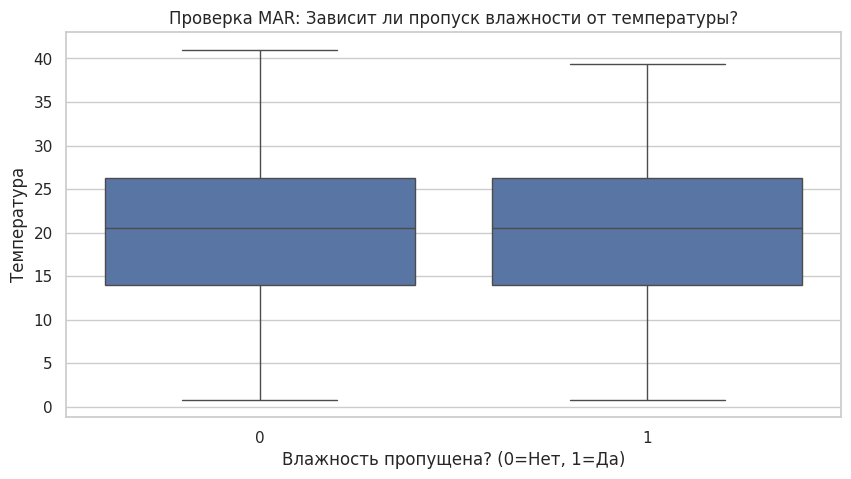

Средняя темп. (данные есть): 20.22
Средняя темп. (пропуск):     20.30
Вывод: Различия минимальны -> MCAR


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df['humidity_missing'] = df['humidity'].isnull().astype(int)

plt.figure(figsize=(10, 5))
sns.boxplot(x='humidity_missing', y='temp', data=df)
plt.title('Проверка MAR: Зависит ли пропуск влажности от температуры?')
plt.xlabel('Влажность пропущена? (0=Нет, 1=Да)')
plt.ylabel('Температура')
plt.show()

temp_present = df[df['humidity_missing']==0]['temp'].mean()
temp_missing = df[df['humidity_missing']==1]['temp'].mean()
print(f"Средняя темп. (данные есть): {temp_present:.2f}")
print(f"Средняя темп. (пропуск):     {temp_missing:.2f}")
print("Вывод: Различия минимальны -> MCAR")

count         0.012
registered    0.011
casual        0.010
windspeed     0.007
workingday    0.004
atemp         0.004
temp          0.003
weather      -0.002
season       -0.008
datetime     -0.013
holiday      -0.013
humidity        NaN
Name: humidity_missing, dtype: float64


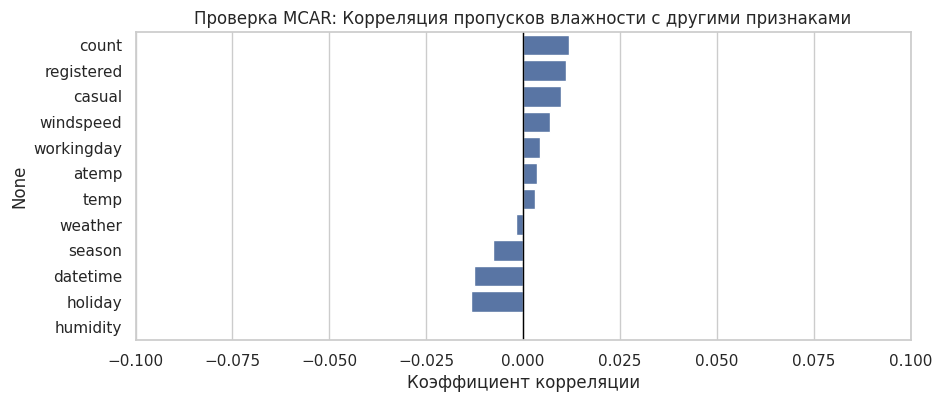

In [8]:
correlations = df.corr()['humidity_missing'].drop('humidity_missing').sort_values(ascending=False)

print(correlations.round(3))

plt.figure(figsize=(10, 4))
sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Проверка MCAR: Корреляция пропусков влажности с другими признаками')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-0.1, 0.1)
plt.show()

**Вывод по проверке MCAR:**  
Как видно из расчетов и по графику, корреляция факта пропуска влажности со всеми остальными признаками практически равна нулю (коэффициенты < 0.02).
Отсутствие сильных корреляций подтверждает **MCAR**.

### Задание 3. Индикатор пропуска как источник информации
1.  **Когда факт пропуска несет информацию?** Когда пропуск не случаен (MNAR). Например, в анкете пропуск графы "Наличие автомобиля" скорее всего означает его отсутствие.
2.  **Сигнал о неправильной импутации:** Если модель присваивает высокий вес индикатору пропуска, значит заполненные значения (средним) сильно искажают реальность, и модель вынуждена использовать индикатор, чтобы отличить реальные данные от выдуманных.
3.  **Примеры:**
    *   *Полезен:* Поле "имя супруга" в анкете. Пропуск сообщает о статусе "холост"
    *   *Бесполезен:* Случайный сбой записи логов на сервере.
    *   *Опасен:* Покупка автомобиля. Поле "Участие в ДТП". Если истории нет (пропуск), а мы заполним это как «Не участвовал» (самое частое значение), мы рискуем сделать ошибку.

## 3. Выбросы

### Задание 4. Выброс - ошибка или сигнал?
Признак: `count`. Значение выброса: **977** (при среднем 191).

1.  **Причины:** Это **сигнал**. Вероятная причина - час пик в хорошую погоду или массовое мероприятие в городе. Это объективная природа данных.
2.  **Что делать (анализ):**
    *   *Удалить:* **Хуже всего.** Мы потеряем информацию о максимальной нагрузке, не сможем планировать ресурсы для праздников.
    *   *Оставить без изменений:* **Приемлемо** для моделей на основе деревьев решений.
    *   *Преобразовать:* **Лучший вариант** для линейных моделей. Использовать логарифмирование, чтобы сгладить влияние экстремальных значений, не удаляя их.



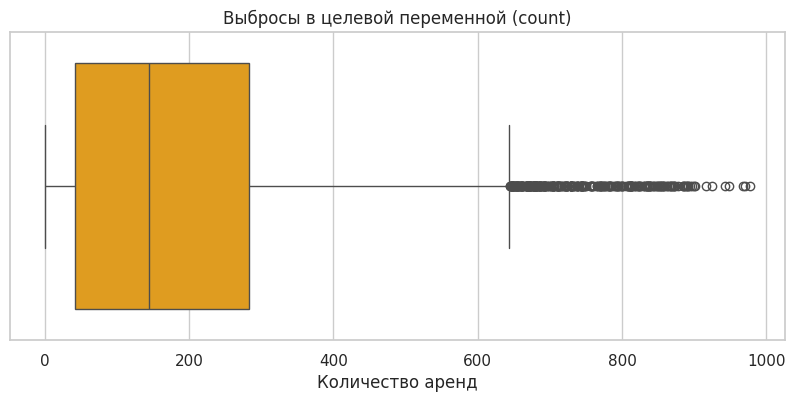

Максимальное значение: 977
Среднее значение: 191.43


In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['count'], color='orange')
plt.title('Выбросы в целевой переменной (count)')
plt.xlabel('Количество аренд')
plt.show()

print(f"Максимальное значение: {df['count'].max()}")
print(f"Среднее значение: {df['count'].mean():.2f}")

## 4. Статистики

### Задание 5. Преобразование или винзоризация?

Анализ методов обработки числового признака с сильной асимметрией (на примере `count`).

#### В каких случаях предпочтительнее:
- **Логарифмирование:**
  * При сильной правосторонней асимметрии (длинный хвост); значения меняются в несколько порядков.
- **Корень:**
  * При умеренной асимметрии. Часто используется для счетных данных (распределение Пуассона).
- **Винзоризация:**
  * Когда экстремальные значения считаются выбросами или ошибками, которые не несут полезной информации.

#### 2. Как эти подходы влияют на:

- **Интерпретируемость:**
  * *Винзоризация:* **Максимальная.** Единицы измерения остаются прежними, избавляемся тоолько от экстремумов.
  * *Логарифм:* **Средняя.** Коэффициенты модели интерпретируются как процентное изменение (эластичность).
  * *Корень:* **Плохая.** Сложно объяснить, что значит "изменение корня из количества велосипедов".
- **Линейные модели:**
  * *Винзоризация:* **Слабо улучшает.** Делает модель устойчивее к отдельным выбросам, но не нормализует распределение.
  * *Логарифм:* **Сильно улучшает.** Лучше всего приводит распределение к нормальному, стабилизирует дисперсию, делает связь линейной.
  * *Корень:* **Средне улучшает.** Улучшает, но слабее логарифма.
- **Визуализацию распределений:**
  * *Винзоризация:* **Искажает.** Сохраняет форму распределения в центре, но создает искусственные вершины на границах.
  * *Логарифм:* **Средняя.** Превращает спад в симметричный "колокол".
  * *Корень:* **Хорошо.** Сжимает хвост, график становится компактнее.

**Вывод для нашего датасета (`count`):**
Мы выбираем **логарифмирование**, так как спрос имеет природу экспоненциального распределения, нам важно нормализовать данные для регрессии.

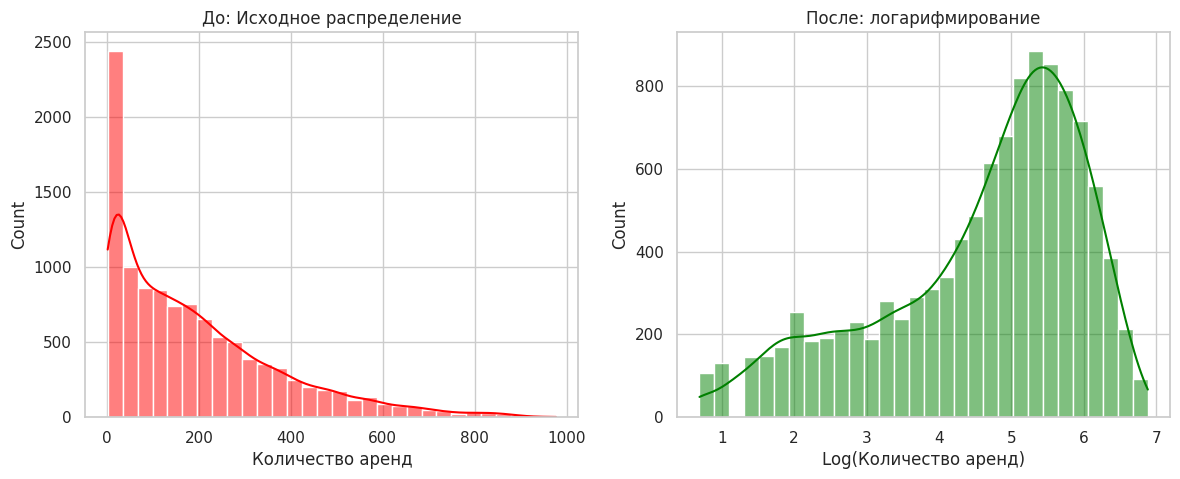

In [ ]:
import numpy as np

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['count'], kde=True, bins=30, color='red')
plt.title('До: Исходное распределение')
plt.xlabel('Количество аренд')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['count']), kde=True, bins=30, color='green')
plt.title('После: логарифмирование')
plt.xlabel('Log(Количество аренд)')

plt.show()

### Задание 6. Средние, которые вводят в заблуждение
Для `count`: mean = 191, median = 145.

1.  **Почему различаются:** Из-за выбросов (длинного правого хвоста). Несколько часов с очень высокой арендой вытягивают среднее арифметическое вверх.
2.  **Что лучше:** **Медиана (145)** лучше отражает "типичное" значение.

In [ ]:
mean_val = df['count'].mean()
median_val = df['count'].median()

print(f"Mean:   {mean_val:.2f}")
print(f"Median: {median_val}")
print(f"Разница: {mean_val - median_val:.2f}")

Mean:   191.43
Median: 145.0
Разница: 46.43


## 5. Визуализация как инструмент мышления

### Задание 7. Неправильная диаграмма
Для отображения зависимости `count` от `temp`.

1.  **Худший выбор: Круговая диаграмма.**
2.  **Ошибки:**
    *   Круговая диаграмма показывает структуру целого, а не корреляцию двух величин.
    *   Визуально невозможно оценить тренд (растет ли спрос с температурой).
    *   Зритель может сделать ложный вывод, что мы сравниваем *доли* температур, а не ищем взаимосвязь.

### Задание 8. Одна и та же информация - разные графики
Пара: `season` (категория) и `count` (число).

1.  **Вариант 1: Столбчатая диаграмма среднего.**
    *   *Подчёркивает:* Разницу в **среднем** объеме аренды между сезонами.
    *   *Скрывает:* Разброс значений и выбросы.
2.  **Вариант 2: Box Plot (Ящик с усами).**
    *   *Подчёркивает:* Распределение, медиану и наличие выбросов в каждом сезоне.
    *   *Легче заметить:* Зимой среднее низкое, но разброс огромный, чего не видно на столбчатой диаграмме.


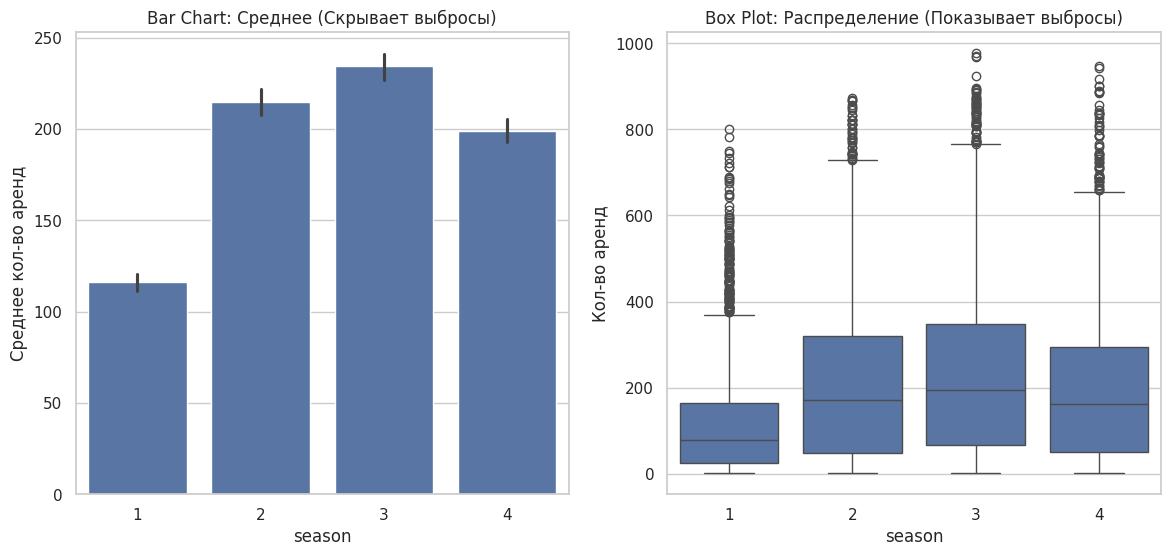

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='season', y='count', data=df)
plt.title('Bar Chart: Среднее (Скрывает выбросы)')
plt.ylabel('Среднее кол-во аренд')

plt.subplot(1, 2, 2)
sns.boxplot(x='season', y='count', data=df)
plt.title('Box Plot: Распределение (Показывает выбросы)')
plt.ylabel('Кол-во аренд')

plt.show()